# Hadamard Test & SWAP Test

## Extracting Expectation Values and State Overlaps with Quantum Interferometry (Qiskit 2.x)

### What This Notebook Covers

1. **Hadamard Test** — extract $\text{Re}\langle\psi|U|\psi\rangle$ and $\text{Im}\langle\psi|U|\psi\rangle$ from ancilla measurements
2. **The Control Tax** — why controlled-$U$ gates make the Hadamard test impractical for routine expectation values
3. **SWAP Test** — measure state overlap $|\langle\phi|\psi\rangle|^2$ via a controlled-SWAP (Fredkin) gate
4. **Overlap Circuits** — the compute-and-invert alternative that avoids expensive controlled operations

Both the Hadamard test and the SWAP test are **quantum interferometric protocols** — they encode information about a unitary's expectation value or two states' overlap into the measurement statistics of a single ancilla qubit. The ancilla acts as a "which-path" detector in a Mach-Zehnder-like interferometer built from Hadamard gates and controlled operations.

| Protocol | What it extracts | Key controlled gate | Ancilla qubits |
|----------|-----------------|---------------------|----------------|
| **Hadamard test** | $\text{Re}\langle\psi\vert U\vert\psi\rangle$ (or $\text{Im}$ with $S^\dagger$) | Controlled-$U$ | 1 |
| **SWAP test** | $\vert\langle\phi\vert\psi\rangle\vert^2$ (state overlap) | Controlled-SWAP (Fredkin) | 1 |

Both are elegant in theory but carry a **control tax** — the controlled version of the target operation is significantly more expensive than the bare operation — which limits their practicality on near-term hardware.

---

## 1. Setup

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import UnitaryGate, unitary_overlap
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_aer import Aer

sampler = AerSampler()
SHOTS = 100_000

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=6, suppress=True)

### Qubit ordering convention (little-endian)

Qiskit uses **little-endian** ordering: qubit 0 is the **rightmost** position in ket notation.

$$|q_{n-1}\, \cdots\, q_1\, q_0\rangle \quad \Longleftarrow \quad \text{qubit 0 is rightmost}$$

Throughout this notebook we follow this convention in all derivations. For example, a 2-qubit register with an ancilla on $q_0$ and data on $q_1$ is written $|\text{data}\rangle|\text{ancilla}\rangle$, **not** $|\text{ancilla}\rangle|\text{data}\rangle$.

In circuit diagrams, Qiskit draws $q_0$ at the **top**.

---

## 2. The Hadamard Test

### What is it?

The **Hadamard test** is a quantum algorithm that extracts the expectation value $\langle\psi|U|\psi\rangle$ of an arbitrary unitary $U$ with respect to a state $|\psi\rangle$, using a single ancilla qubit. It works by encoding the real (or imaginary) part of this complex number into the measurement probabilities of the ancilla.

### Where is it used?

- **Variational algorithms** — computing cost function gradients involving non-Hermitian terms
- **Quantum phase estimation (QPE)** — the Hadamard test is the single-qubit building block of iterative QPE
- **Quantum chemistry** — evaluating transition amplitudes $\langle\phi|U|\psi\rangle$ (generalised Hadamard test)
- **Quantum machine learning** — computing kernel entries that involve unitary overlaps

### Key distinction from Hermitian expectation values

For a **Hermitian** observable $H = H^\dagger$, the expectation value $\langle\psi|H|\psi\rangle$ is always **real**. This is why the Estimator primitive returns a single real number.

For a general **unitary** $U$, the expectation value $\langle\psi|U|\psi\rangle$ is **complex** — it has both real and imaginary parts. The Hadamard test extracts these separately:

- **Standard circuit** (no extra gate) $\;\longrightarrow\;$ $\text{Re}\langle\psi|U|\psi\rangle$
- **With $S^\dagger$ before final $H$** $\;\longrightarrow\;$ $\text{Im}\langle\psi|U|\psi\rangle$

### Derivation

The circuit uses $q_0$ = ancilla and $q_1$ = data register holding $|\psi\rangle$. Following Qiskit's little-endian convention, $q_0$ appears **rightmost** in ket notation: $|q_1\, q_0\rangle = |\text{data}\rangle|\text{ancilla}\rangle$.

```
          ┌───┐                    ┌───┐
q_0 (a): ─┤ H ├───────■────────────┤ H ├── Measure
          └───┘       │            └───┘
                  ┌───┴───┐
q_1 (b): |ψ⟩──────┤   U   ├────────────────
                  └───────┘
```

**Step 1 — Initial state** (data on left, ancilla on right):

$$|\Psi_0\rangle = |\psi\rangle \otimes |0\rangle = |\psi\rangle|0\rangle$$

**Step 2 — Hadamard on $q_0$ (ancilla):**

$$|\Psi_1\rangle = |\psi\rangle \otimes \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr) = \frac{1}{\sqrt{2}}\bigl(|\psi\rangle|0\rangle + |\psi\rangle|1\rangle\bigr)$$

**Step 3 — Controlled-$U$** (applies $U$ to $q_1$ when $q_0 = |1\rangle$):

$$|\Psi_2\rangle = \frac{1}{\sqrt{2}}\bigl(|\psi\rangle|0\rangle + U|\psi\rangle|1\rangle\bigr)$$

**Step 4 — Final Hadamard on $q_0$** (using $H|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ and $H|1\rangle = \frac{1}{\sqrt{2}}(|0\rangle-|1\rangle)$):

$$|\Psi_3\rangle = \frac{1}{2}(I + U)|\psi\rangle \otimes |0\rangle + \frac{1}{2}(I - U)|\psi\rangle \otimes |1\rangle$$

**Step 5 — Probability of measuring $q_0 = 0$:**

$$P(0) = \left\|\frac{1}{2}(I+U)|\psi\rangle\right\|^2 = \frac{1}{4}\langle\psi|(I+U^\dagger)(I+U)|\psi\rangle$$

Expanding:

$$P(0) = \frac{1}{4}\langle\psi|(I + U^\dagger + U + U^\dagger U)|\psi\rangle$$

Since $U$ is unitary ($U^\dagger U = I$):

$$P(0) = \frac{1}{4}\langle\psi|(2I + U + U^\dagger)|\psi\rangle = \frac{1}{2} + \frac{1}{4}\langle\psi|(U + U^\dagger)|\psi\rangle$$

Recognising that $\frac{1}{2}(U + U^\dagger)$ extracts the real part:

$$\boxed{P(0) = \frac{1}{2} + \frac{1}{2}\,\text{Re}\langle\psi|U|\psi\rangle}$$

Therefore: $\;\text{Re}\langle\psi|U|\psi\rangle = P(0) - P(1) = 2P(0) - 1$.

### Extracting the imaginary part

Inserting $S^\dagger$ on $q_0$ before the final $H$ gives the phase shift $S^\dagger|1\rangle = -i|1\rangle$, rotating the interference by $90°$:

$$P(0) = \frac{1}{2} + \frac{1}{2}\,\text{Im}\langle\psi|U|\psi\rangle$$

Combining both circuits: $\langle\psi|U|\psi\rangle = \text{Re} + i\,\text{Im}$.

### Circuit demonstration

We pick a concrete unitary $U = R_z(\pi/3) \cdot R_y(\pi/4)$ acting on one qubit, and a non-trivial input state $|\psi\rangle = R_y(\pi/5)|0\rangle$. Since $U$ is unitary but not Hermitian, $\langle\psi|U|\psi\rangle$ will generally be **complex**.

We build both circuits (real and imaginary parts), extract probabilities from statevector simulation, and compare against the direct calculation $\langle\psi|U|\psi\rangle = \langle\psi| \cdot U|\psi\rangle$.

In [21]:
# ---- Define U and |psi> ----
qc_u = QuantumCircuit(1, name='U')
qc_u.ry(np.pi/4, 0)
qc_u.rz(np.pi/3, 0)

U_gate = UnitaryGate(Operator(qc_u), label='U')
cU_gate = U_gate.control(1)

qc_psi = QuantumCircuit(1, name='psi_prep')
qc_psi.ry(np.pi/5, 0)
psi = Statevector(qc_psi)

# ---- Direct calculation: <psi|U|psi> ----
U_matrix = Operator(qc_u).data
exp_val_direct = psi.data.conj() @ U_matrix @ psi.data

print(f"Direct calculation:")
print(f"  <psi|U|psi> = {exp_val_direct:.6f}")
print(f"  Re part     = {exp_val_direct.real:.6f}")
print(f"  Im part     = {exp_val_direct.imag:.6f}")
print(f"  |<psi|U|psi>| = {abs(exp_val_direct):.6f}")
print(f"\n  Note: expectation value is complex (not real), since U is unitary but not Hermitian.")

Direct calculation:
  <psi|U|psi> = 0.800103-0.261249j
  Re part     = 0.800103
  Im part     = -0.261249
  |<psi|U|psi>| = 0.841675

  Note: expectation value is complex (not real), since U is unitary but not Hermitian.


Now we build the two Hadamard test circuits — one for the real part (standard) and one for the imaginary part (with $S^\dagger$).

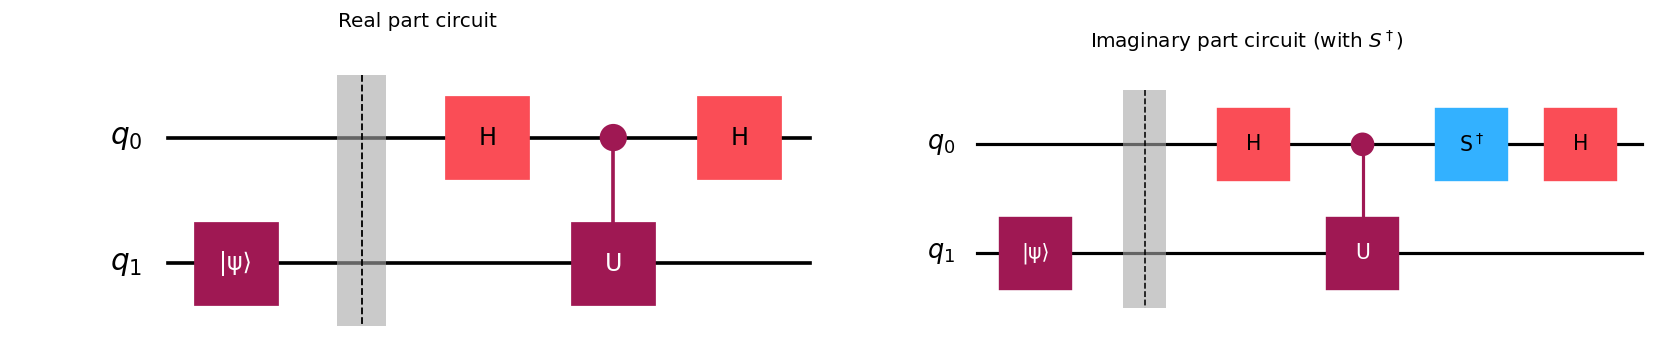

In [30]:
def hadamard_test_circuit(U_gate, psi_prep, imaginary=False):
    """Build a Hadamard test circuit.

    Args:
        U_gate: UnitaryGate for the target unitary
        psi_prep: QuantumCircuit preparing |psi> on 1 qubit
        imaginary: if True, add S† to extract Im part
    """
    qc = QuantumCircuit(2)
    qc.append(psi_prep.to_gate(label='|ψ⟩'), [1])
    qc.barrier()
    qc.h(0)
    qc.append(U_gate.control(1), [0, 1])
    if imaginary:
        qc.sdg(0)
    qc.h(0)
    return qc

# ---- Real-part circuit ----
had_re = hadamard_test_circuit(U_gate, qc_psi, imaginary=False)
had_re.name = 'Hadamard Test (Re)'

# ---- Imaginary-part circuit ----
had_im = hadamard_test_circuit(U_gate, qc_psi, imaginary=True)
had_im.name = 'Hadamard Test (Im)'

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
had_re.draw('mpl', style='iqp', ax=axes[0])
axes[0].set_title('Real part circuit', fontsize=12)
had_im.draw('mpl', style='iqp', ax=axes[1])
axes[1].set_title('Imaginary part circuit (with $S^\\dagger$)', fontsize=12)
plt.tight_layout()
plt.show()

### Extracting the expectation value

We simulate both circuits using `Statevector`, extract $P(0)$ from each, and reconstruct $\langle\psi|U|\psi\rangle$.

In [32]:
def p0_ancilla(circuit, shots=SHOTS):
    """Probability of measuring ancilla (qubit 0) as |0> using AerSamplerV2."""
    meas_qc = circuit.copy()
    meas_qc.measure_all()
    transpiled_qc = transpile(meas_qc, backend)
    result = sampler.run([transpiled_qc], shots=shots).result()
    counts = result[0].data.meas.get_counts()
    total = sum(counts.values())
    p0 = sum(v for k, v in counts.items() if k[-1] == '0') / total
    return p0

backend = Aer.get_backend("aer_simulator")

P0_re = p0_ancilla(had_re)
P0_im = p0_ancilla(had_im)

re_hadamard = 2 * P0_re - 1
im_hadamard = 2 * P0_im - 1

exp_val_hadamard = re_hadamard + 1j * im_hadamard

print("=== Hadamard Test Results (AerSamplerV2, {} shots) ===\n".format(SHOTS))
print(f"  Real-part circuit:  P(0) = {P0_re:.6f}  =>  Re = 2*P(0)-1 = {re_hadamard:.6f}")
print(f"  Imag-part circuit:  P(0) = {P0_im:.6f}  =>  Im = 2*P(0)-1 = {im_hadamard:.6f}")
print(f"\n  Hadamard test: <psi|U|psi> = {exp_val_hadamard:.6f}")
print(f"  Direct calc:   <psi|U|psi> = {exp_val_direct:.6f}")
print(f"\n  Match (atol=0.01): {np.isclose(exp_val_hadamard, exp_val_direct, atol=0.01)}")

=== Hadamard Test Results (AerSamplerV2, 100000 shots) ===

  Real-part circuit:  P(0) = 0.900710  =>  Re = 2*P(0)-1 = 0.801420
  Imag-part circuit:  P(0) = 0.369630  =>  Im = 2*P(0)-1 = -0.260740

  Hadamard test: <psi|U|psi> = 0.801420-0.260740j
  Direct calc:   <psi|U|psi> = 0.800103-0.261249j

  Match (atol=0.01): True


### The Control Tax: why Hadamard tests aren't used routinely

The Hadamard test is mathematically elegant but carries a steep practical cost — the **control tax**.

**The problem:** To run the Hadamard test, we need a **controlled-$U$** gate. Adding a control qubit to an arbitrary $n$-qubit unitary roughly **doubles its CNOT count** (and sometimes worse). For a circuit $U$ that decomposes into $G$ two-qubit gates, controlled-$U$ typically requires $O(G)$ additional CNOTs plus ancilla management.

**For Hermitian observables** (the common case in VQE, QAOA, etc.), the Estimator primitive decomposes $H$ into a sum of Paulis $H = \sum_i c_i P_i$ and measures each $P_i$ directly — no controlled gates needed. This is far cheaper.

| Approach | Gate overhead | When to use |
|----------|--------------|-------------|
| **Estimator** (Pauli decomposition) | Bare $U$ + single-qubit rotations | Hermitian observables (standard case) |
| **Hadamard test** | Controlled-$U$ ($\approx 2\times$ CNOTs) | Non-Hermitian unitaries, phase estimation, transition amplitudes |

The Hadamard test is reserved for situations where you genuinely need $\langle\psi|U|\psi\rangle$ for a **non-Hermitian** $U$ — such as iterative QPE or computing off-diagonal matrix elements.

In [33]:
bare_u = QuantumCircuit(1)
bare_u.ry(np.pi/4, 0)
bare_u.rz(np.pi/3, 0)

ctrl_u = QuantumCircuit(2)
ctrl_u.append(U_gate.control(1), [0, 1])

bare_decomp = transpile(bare_u, basis_gates=['cx', 'rz', 'sx', 'x'], optimization_level=2)
ctrl_decomp = transpile(ctrl_u, basis_gates=['cx', 'rz', 'sx', 'x'], optimization_level=2)

bare_cx = bare_decomp.count_ops().get('cx', 0)
ctrl_cx = ctrl_decomp.count_ops().get('cx', 0)

print("=== Control Tax Demonstration ===\n")
print(f"  Bare U:       {bare_cx} CX gates,  {sum(bare_decomp.count_ops().values())} total gates")
print(f"  Controlled-U: {ctrl_cx} CX gates,  {sum(ctrl_decomp.count_ops().values())} total gates")
print(f"\n  CX overhead ratio: {ctrl_cx / max(bare_cx, 1):.1f}x"
      if bare_cx > 0 else f"\n  Bare U has 0 CX; controlled-U needs {ctrl_cx} CX gates")

=== Control Tax Demonstration ===

  Bare U:       0 CX gates,  4 total gates
  Controlled-U: 2 CX gates,  17 total gates

  Bare U has 0 CX; controlled-U needs 2 CX gates


---

## 3. The SWAP Test

### What is it?

The **SWAP test** is a quantum protocol that measures the overlap $|\langle\phi|\psi\rangle|^2$ between two quantum states $|\phi\rangle$ and $|\psi\rangle$ using a single ancilla qubit and a controlled-SWAP (Fredkin) gate. It answers the question: *how similar are these two states?*

### Use cases

- **State comparison** — testing if two quantum states are identical without full tomography
- **Fidelity estimation** — for pure states, $|\langle\phi|\psi\rangle|^2$ is exactly the squared fidelity $F^2$
- **Quantum fingerprinting** — exponentially compact state comparison in communication complexity
- **Quantum machine learning** — computing kernel entries $|\langle\phi_i|\phi_j\rangle|^2$ for quantum kernel methods


### Derivation

The circuit uses $q_0$ = ancilla, $q_1$ = $|\phi\rangle$ register, $q_2$ = $|\psi\rangle$ register. In Qiskit's little-endian convention: $|q_2\, q_1\, q_0\rangle = |\psi\rangle|\phi\rangle|\text{ancilla}\rangle$.

```
              ┌───┐                      ┌───┐
q_0 (a):    ──┤ H ├───────■──────────────┤ H ├── Measure
              └───┘       │              └───┘
                     ┌────┴────┐
q_1 (|φ⟩): |φ⟩────────┤         ├─────────────
                     │  SWAP   │
q_2 (|ψ⟩): |ψ⟩────────┤         ├─────────────
                     └─────────┘
```

**Step 1 — Initial state** ($q_2$ leftmost, $q_0$ rightmost):

$$|\Psi_0\rangle = |\psi\rangle|\phi\rangle|0\rangle$$

**Step 2 — Hadamard on $q_0$ (ancilla):**

$$|\Psi_1\rangle = |\psi\rangle|\phi\rangle \otimes \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr)$$

**Step 3 — Controlled-SWAP** (swaps $q_1 \leftrightarrow q_2$ when $q_0 = |1\rangle$):

$$|\Psi_2\rangle = \frac{1}{\sqrt{2}}\bigl(|\psi\rangle|\phi\rangle|0\rangle + |\phi\rangle|\psi\rangle|1\rangle\bigr)$$

**Step 4 — Final Hadamard on $q_0$:**

$$|\Psi_3\rangle = \frac{1}{2}\bigl(|\psi\rangle|\phi\rangle + |\phi\rangle|\psi\rangle\bigr)|0\rangle + \frac{1}{2}\bigl(|\psi\rangle|\phi\rangle - |\phi\rangle|\psi\rangle\bigr)|1\rangle$$

**Step 5 — Probability of measuring $q_0 = 0$:**

$$P(0) = \frac{1}{4}\bigl\||\psi\rangle|\phi\rangle + |\phi\rangle|\psi\rangle\bigr\|^2$$

Expanding and using $\langle\phi|\psi\rangle\langle\psi|\phi\rangle = |\langle\phi|\psi\rangle|^2$:

$$P(0) = \frac{1}{2} + \frac{1}{2}|\langle\phi|\psi\rangle|^2$$

Therefore:

$$\boxed{|\langle\phi|\psi\rangle|^2 = 2P(0) - 1}$$

### Key insights

- **Identical states** ($|\phi\rangle = |\psi\rangle$): overlap $= 1$, so $P(0) = 1$.

- **Orthogonal states** ($\langle\phi|\psi\rangle = 0$): overlap $= 0$, so $P(0) = 1/2$.

### Circuit demonstration

We prepare two single-qubit states $|\phi\rangle = R_y(\pi/3)|0\rangle$ and $|\psi\rangle = R_y(\pi/5)|0\rangle$, run the SWAP test, and verify the overlap against the direct inner product $|\langle\phi|\psi\rangle|^2$.

In [34]:
# ---- Prepare |phi> and |psi> ----
qc_phi = QuantumCircuit(1, name='phi_prep')
qc_phi.ry(np.pi/3, 0)

qc_psi2 = QuantumCircuit(1, name='psi_prep')
qc_psi2.ry(np.pi/5, 0)

phi_sv = Statevector(qc_phi)
psi_sv = Statevector(qc_psi2)

overlap_direct = np.abs(phi_sv.data.conj() @ psi_sv.data)**2
print(f"|phi> = Ry(pi/3)|0> = {phi_sv.data.round(4)}")
print(f"|psi> = Ry(pi/5)|0> = {psi_sv.data.round(4)}")
print(f"\nDirect: |<phi|psi>|^2 = {overlap_direct:.6f}")

|phi> = Ry(pi/3)|0> = [0.866+0.j 0.5  +0.j]
|psi> = Ry(pi/5)|0> = [0.9511+0.j 0.309 +0.j]

Direct: |<phi|psi>|^2 = 0.956773


Build the SWAP test circuit. Qubit layout: $q_0$ = ancilla, $q_1$ = $|\phi\rangle$ register, $q_2$ = $|\psi\rangle$ register. In ket notation (little-endian): $|q_2\, q_1\, q_0\rangle$.

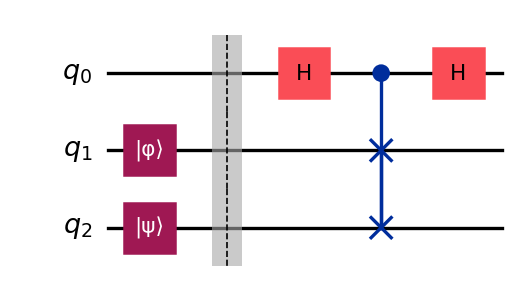

In [35]:
swap_test = QuantumCircuit(3, name='SWAP Test')

swap_test.append(qc_phi.to_gate(label='|φ⟩'), [1])
swap_test.append(qc_psi2.to_gate(label='|ψ⟩'), [2])
swap_test.barrier()

swap_test.h(0)
swap_test.cswap(0, 1, 2)
swap_test.h(0)

swap_test.draw('mpl', style='iqp')

### Extracting the overlap

In [36]:
P0_swap = p0_ancilla(swap_test)
overlap_swap = 2 * P0_swap - 1

print("=== SWAP Test Results (AerSamplerV2, {} shots) ===\n".format(SHOTS))
print(f"  P(0) = {P0_swap:.6f}")
print(f"  |<phi|psi>|^2 = 2*P(0) - 1 = {overlap_swap:.6f}")
print(f"  Direct calculation:           {overlap_direct:.6f}")
print(f"\n  Match (atol=0.01): {np.isclose(overlap_swap, overlap_direct, atol=0.01)}")

=== SWAP Test Results (AerSamplerV2, 100000 shots) ===

  P(0) = 0.977920
  |<phi|psi>|^2 = 2*P(0) - 1 = 0.955840
  Direct calculation:           0.956773

  Match (atol=0.01): True


### Verifying the boundary cases

Let's confirm that identical states give $P(0) = 1$ and orthogonal states give $P(0) = 0.5$.

In [37]:
def run_swap_test(prep_a, prep_b):
    """Run a SWAP test and return P(0) for the ancilla using AerSamplerV2."""
    qc = QuantumCircuit(3)
    qc.append(prep_a.to_gate(), [1])
    qc.append(prep_b.to_gate(), [2])
    qc.h(0)
    qc.cswap(0, 1, 2)
    qc.h(0)
    return p0_ancilla(qc)

# ---- Identical states: |+> and |+> ----
prep_plus = QuantumCircuit(1)
prep_plus.h(0)

P0_identical = run_swap_test(prep_plus, prep_plus)

# ---- Orthogonal states: |0> and |1> ----
prep_0 = QuantumCircuit(1)
prep_1 = QuantumCircuit(1)
prep_1.x(0)

P0_orthogonal = run_swap_test(prep_0, prep_1)

# ---- Partial overlap: |0> and |+> ----
P0_partial = run_swap_test(prep_0, prep_plus)

print("=== Boundary Cases (AerSamplerV2, {} shots) ===\n".format(SHOTS))
print(f"  Identical (|+>, |+>):    P(0) = {P0_identical:.4f},  overlap = {2*P0_identical-1:.4f}  (expected 1.0)")
print(f"  Orthogonal (|0>, |1>):   P(0) = {P0_orthogonal:.4f},  overlap = {2*P0_orthogonal-1:.4f}  (expected 0.0)")
print(f"  Partial (|0>, |+>):      P(0) = {P0_partial:.4f},  overlap = {2*P0_partial-1:.4f}  (expected 0.5)")

=== Boundary Cases (AerSamplerV2, 100000 shots) ===

  Identical (|+>, |+>):    P(0) = 1.0000,  overlap = 1.0000  (expected 1.0)
  Orthogonal (|0>, |1>):   P(0) = 0.5023,  overlap = 0.0045  (expected 0.0)
  Partial (|0>, |+>):      P(0) = 0.7530,  overlap = 0.5061  (expected 0.5)


### The Hardware Barrier: why SWAP tests aren't used for routine overlaps

While mathematically beautiful, the SWAP test suffers from a severe practical limitation: the **Fredkin gate** (controlled-SWAP) is extremely expensive on real hardware.

A single Fredkin gate decomposes into **at least 6-8 CNOT gates** plus single-qubit rotations. For $n$-qubit states, you need $n$ controlled-SWAPs (one per qubit pair), making the total cost $O(n)$ Fredkin gates $= O(n)$ expensive multi-qubit operations.

The **compute-and-invert** (overlap) circuit provides a much cheaper alternative when the states are prepared by known circuits $U_1|0\rangle = |\phi\rangle$ and $U_2|0\rangle = |\psi\rangle$:

```
        ┌────┐┌──────┐┌───┐
  |0⟩ ──┤ U₁ ├┤ U₂†  ├┤ M ├   P(all zeros) = |<φ|ψ>|²
        └────┘└──────┘└───┘
```

Apply $U_1$ then $U_2^\dagger$. The probability of measuring all-zeros is exactly $|\langle\phi|\psi\rangle|^2 = |\langle 0|U_1^\dagger U_2|0\rangle|^2$. No ancilla, no controlled-SWAPs.

| Feature | Compute-and-Invert (Overlap Circuit) | SWAP Test |
|---------|--------------------------------------|-----------|
| **Circuit strategy** | Apply $U_1$ then $U_2^\dagger$ | Interferometry: ancilla controls a SWAP between two registers |
| **Qubits needed** | $n$ qubits (same as data) | $2n + 1$ qubits (doubles the data qubits + 1 ancilla) |
| **Key gate** | Bare $U_1$, $U_2^\dagger$ (no control overhead) | Controlled-SWAP (Fredkin) — 6-8 CNOTs each |
| **Hardware fit** | Much better for NISQ: fewer qubits, no controlled-SWAPs | Harder: Fredkin gates are very noisy on real hardware |
| **Limitation** | Requires knowing the preparation circuits $U_1$, $U_2$ | Works even with unknown (black-box) state preparations |

### Side-by-side: SWAP test vs overlap circuit

Let's build both circuits for the same pair of states and compare their gate costs after transpilation.

In [38]:
# ---- SWAP test circuit (3 qubits: ancilla + 2 data) ----
swap_circ = QuantumCircuit(3, name='SWAP Test')
swap_circ.append(qc_phi.to_gate(label='|φ⟩'), [1])
swap_circ.append(qc_psi2.to_gate(label='|ψ⟩'), [2])
swap_circ.h(0)
swap_circ.cswap(0, 1, 2)
swap_circ.h(0)

# ---- Overlap (compute-and-invert) circuit (1 qubit, no ancilla) ----
overlap_circ = QuantumCircuit(1, name='Overlap Circuit')
overlap_circ.append(qc_phi.to_gate(label='|φ⟩'), [0])
overlap_circ.append(qc_psi2.to_gate(label='|ψ⟩').inverse(), [0])

# ---- Transpile both for gate cost comparison ----
swap_decomp = transpile(swap_circ, basis_gates=['cx', 'rz', 'sx', 'x'], optimization_level=2)
overlap_decomp = transpile(overlap_circ, basis_gates=['cx', 'rz', 'sx', 'x'], optimization_level=2)

swap_ops = swap_decomp.count_ops()
overlap_ops = overlap_decomp.count_ops()

print("=== Gate Cost Comparison ===\n")
print(f"  SWAP test circuit:")
print(f"    Qubits: {swap_decomp.num_qubits},  CX: {swap_ops.get('cx', 0)},  Total gates: {sum(swap_ops.values())}")
print(f"    Gate breakdown: {dict(swap_ops)}")
print(f"\n  Overlap (compute-and-invert) circuit:")
print(f"    Qubits: {overlap_decomp.num_qubits},  CX: {overlap_ops.get('cx', 0)},  Total gates: {sum(overlap_ops.values())}")
print(f"    Gate breakdown: {dict(overlap_ops)}")

# ---- Verify overlap circuit via sampler ----
p_all_zero = p0_ancilla(overlap_circ)

print(f"\n  Overlap circuit P(0) = {p_all_zero:.6f}  =>  |<phi|psi>|^2 = {p_all_zero:.6f}")
print(f"  SWAP test result:                          |<phi|psi>|^2 = {overlap_swap:.6f}")
print(f"  Direct calculation:                        |<phi|psi>|^2 = {overlap_direct:.6f}")

=== Gate Cost Comparison ===

  SWAP test circuit:
    Qubits: 3,  CX: 7,  Total gates: 32
    Gate breakdown: {'rz': 16, 'sx': 9, 'cx': 7}

  Overlap (compute-and-invert) circuit:
    Qubits: 1,  CX: 0,  Total gates: 4
    Gate breakdown: {'rz': 2, 'sx': 2}

  Overlap circuit P(0) = 0.956600  =>  |<phi|psi>|^2 = 0.956600
  SWAP test result:                          |<phi|psi>|^2 = 0.955840
  Direct calculation:                        |<phi|psi>|^2 = 0.956773


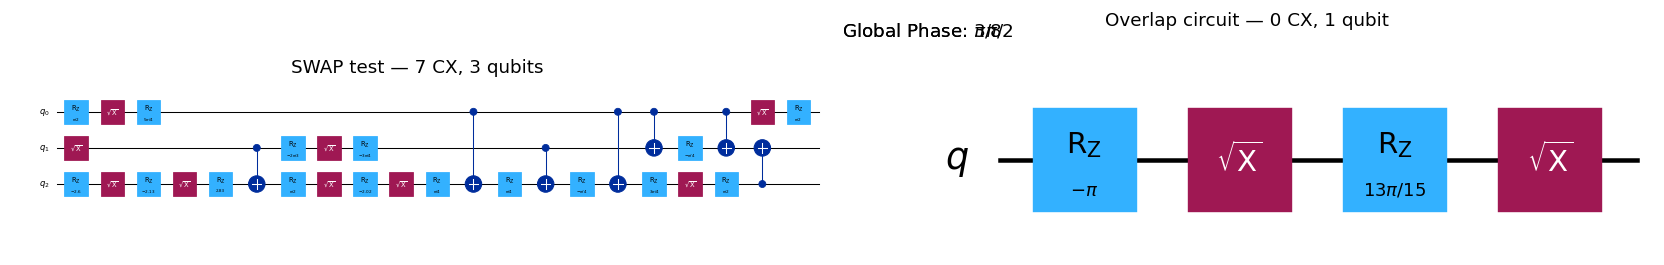

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
swap_decomp.draw('mpl', style='iqp', ax=axes[0])
axes[0].set_title(f'SWAP test — {swap_ops.get("cx",0)} CX, {swap_decomp.num_qubits} qubits', fontsize=11)
overlap_decomp.draw('mpl', style='iqp', ax=axes[1])
axes[1].set_title(f'Overlap circuit — {overlap_ops.get("cx",0)} CX, {overlap_decomp.num_qubits} qubit', fontsize=11)
plt.tight_layout()
plt.show()

### Using `unitary_overlap` from Qiskit's circuit library

Qiskit provides `unitary_overlap(unitary1, unitary2)` which builds the compute-and-invert circuit $U_1 \cdot U_2^\dagger$ automatically. This is the recommended way to construct overlap circuits — it handles the inversion and composition internally.

=== unitary_overlap Result (AerSamplerV2, 100000 shots) ===

  P(0) = 0.956830  =>  |<phi|psi>|^2 = 0.956830
  Manual overlap circuit:                    0.956600
  Direct calculation:                        0.956773

  Circuit depth = 3


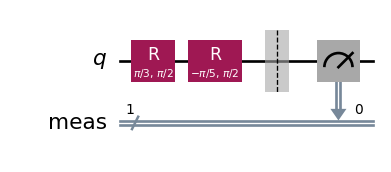

In [45]:
# ---- unitary_overlap builds U1 · U2† automatically ----
uo_circ = unitary_overlap(qc_phi, qc_psi2)
uo_circ.measure_all()

uo_decomp = transpile(uo_circ, backend)
result_uo = sampler.run([uo_decomp], shots=SHOTS).result()
counts_uo = result_uo[0].data.meas.get_counts()
p0_uo = counts_uo.get('0', 0) / sum(counts_uo.values())

print("=== unitary_overlap Result (AerSamplerV2, {} shots) ===\n".format(SHOTS))
print(f"  P(0) = {p0_uo:.6f}  =>  |<phi|psi>|^2 = {p0_uo:.6f}")
print(f"  Manual overlap circuit:                    {p_all_zero:.6f}")
print(f"  Direct calculation:                        {overlap_direct:.6f}")
print(f"\n  Circuit depth = {uo_circ.decompose().depth()}")

uo_circ.decompose().draw('mpl', scale=0.8, style='iqp')

---

## 5. Summary

### The three protocols at a glance

| Protocol | Extracts | Key gate | Qubits | When to use |
|----------|----------|----------|--------|-------------|
| **Hadamard test** | $\text{Re/Im}\langle\psi\vert U\vert\psi\rangle$ | Controlled-$U$ | $n + 1$ | Non-Hermitian expectation values, iterative QPE, transition amplitudes |
| **SWAP test** | $\vert\langle\phi\vert\psi\rangle\vert^2$ | Controlled-SWAP | $2n + 1$ | Black-box state comparison, quantum fingerprinting |
| **Overlap circuit** | $\vert\langle\phi\vert\psi\rangle\vert^2$ | Bare $U_1$, $U_2^\dagger$ | $n$ | Known preparation circuits (most practical for NISQ) |

### Key takeaways

1. **Hadamard test** and **SWAP test** are interferometric: they encode information into ancilla measurement statistics via controlled operations. Elegant, but the **control tax** makes them expensive on near-term hardware.

2. **Overlap circuits** (compute-and-invert) avoid controlled gates entirely by running $U_1$ then $U_2^\dagger$ and measuring the all-zeros probability. This is the go-to method when you know the state preparation circuits.

3. For **Hermitian observables**, the Estimator primitive with Pauli decomposition is almost always cheaper than the Hadamard test. Reserve the Hadamard test for genuinely non-Hermitian $U$.

4. The **SWAP test** shines in the black-box setting (unknown state preparations) and in quantum communication complexity, but its $2n+1$ qubit cost and Fredkin gate overhead make it impractical for routine overlap estimation on current hardware.

---

## References

- M. A. Nielsen & I. L. Chuang, *Quantum Computation and Quantum Information* 
- [Qiskit SDK Documentation — Little-endian convention](https://docs.quantum.ibm.com/api/qiskit/conventions)
- Workshop on Quantum Computing: Theory, Algorithms & Reality @ IISC Bengaluru, March 2026

---

## Disclosure

In [42]:
import qiskit
import sys

print("--- Disclosure ---")
print("AI tool used - Claude Code (Claude Opus 4.6, Anthropic)")
print(f"\nLibrary versions:")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  Qiskit     : {qiskit.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Matplotlib : {plt.matplotlib.__version__}")

--- Disclosure ---
AI tool used - Claude Code (Claude Opus 4.6, Anthropic)

Library versions:
  Python     : 3.11.5
  Qiskit     : 2.3.0
  NumPy      : 2.3.3
  Matplotlib : 3.10.7
